In [5]:
!pip install tensorflow pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\Sagar\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [7]:
loan_df = pd.DataFrame({

    'credit.policy':[1,1,0,1,0,1,1,0,1,0,1,0],

    'purpose':[
        'credit_card',
        'debt_consolidation',
        'small_business',
        'credit_card',
        'all_other',
        'major_purchase',
        'educational',
        'small_business',
        'credit_card',
        'all_other',
        'debt_consolidation',
        'major_purchase'
    ],

    'int.rate':[0.11,0.13,0.18,0.10,0.20,0.12,0.14,0.19,0.09,0.21,0.15,0.16],

    'installment':[300,250,450,200,500,280,320,470,220,530,310,340],

    'log.annual.inc':[11.1,10.8,10.2,11.5,10.0,11.0,10.7,10.1,11.6,9.9,10.9,10.5],

    'dti':[12,18,25,10,30,15,17,28,9,35,20,22],

    'fico':[720,680,600,750,580,710,690,610,760,570,670,650],

    'days.with.cr.line':[4000,3500,2000,4500,1800,3900,3600,2100,4700,1600,3400,3000],

    'revol.bal':[5000,7000,12000,4000,15000,6000,6500,13000,3500,17000,7500,8500],

    'revol.util':[35,50,80,25,90,40,45,85,20,95,60,65],

    'inq.last.6mths':[1,2,5,0,6,1,2,5,0,7,3,4],

    'delinq.2yrs':[0,1,3,0,4,1,0,3,0,5,2,2],

    'pub.rec':[0,0,1,0,2,0,0,1,0,2,1,1],

    'not.fully.paid':[0,0,1,0,1,0,0,1,0,1,1,1]
})

loan_df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,credit_card,0.11,300,11.1,12,720,4000,5000,35,1,0,0,0
1,1,debt_consolidation,0.13,250,10.8,18,680,3500,7000,50,2,1,0,0
2,0,small_business,0.18,450,10.2,25,600,2000,12000,80,5,3,1,1
3,1,credit_card,0.10,200,11.5,10,750,4500,4000,25,0,0,0,0
4,0,all_other,0.20,500,10.0,30,580,1800,15000,90,6,4,2,1


In [8]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      12 non-null     int64  
 1   purpose            12 non-null     object 
 2   int.rate           12 non-null     float64
 3   installment        12 non-null     int64  
 4   log.annual.inc     12 non-null     float64
 5   dti                12 non-null     int64  
 6   fico               12 non-null     int64  
 7   days.with.cr.line  12 non-null     int64  
 8   revol.bal          12 non-null     int64  
 9   revol.util         12 non-null     int64  
 10  inq.last.6mths     12 non-null     int64  
 11  delinq.2yrs        12 non-null     int64  
 12  pub.rec            12 non-null     int64  
 13  not.fully.paid     12 non-null     int64  
dtypes: float64(2), int64(11), object(1)
memory usage: 1.4+ KB


In [9]:
loan_df.isnull().sum()

credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64

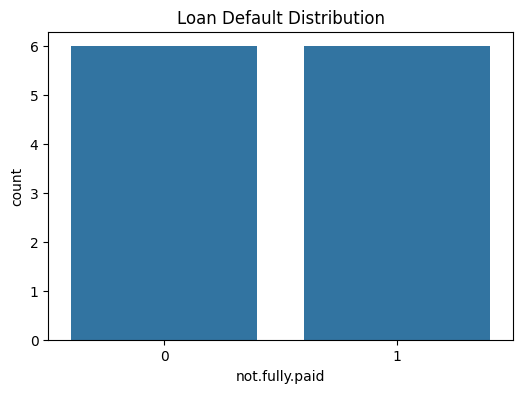

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(x='not.fully.paid', data=loan_df)

plt.title('Loan Default Distribution')

plt.show()

In [11]:
encoder = LabelEncoder()

loan_df['purpose'] = encoder.fit_transform(loan_df['purpose'])

loan_df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,1,0.11,300,11.1,12,720,4000,5000,35,1,0,0,0
1,1,2,0.13,250,10.8,18,680,3500,7000,50,2,1,0,0
2,0,5,0.18,450,10.2,25,600,2000,12000,80,5,3,1,1
3,1,1,0.10,200,11.5,10,750,4500,4000,25,0,0,0,0
4,0,0,0.20,500,10.0,30,580,1800,15000,90,6,4,2,1


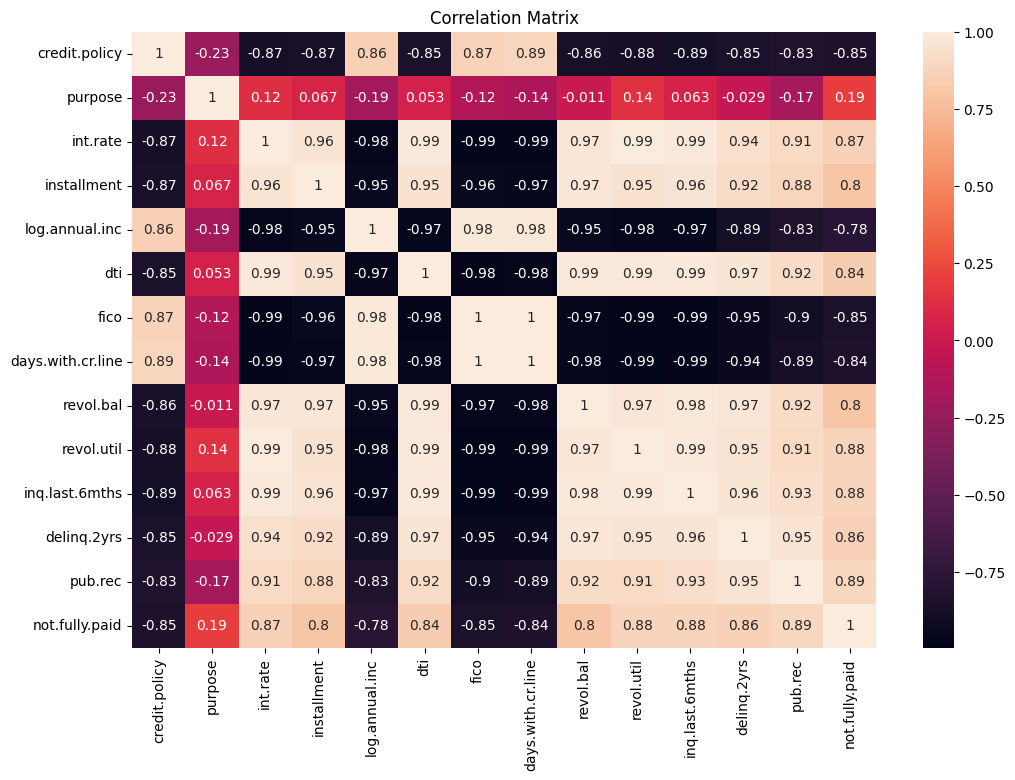

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(loan_df.corr(), annot=True)

plt.title('Correlation Matrix')

plt.show()

In [13]:
X = loan_df.drop('not.fully.paid', axis=1)

y = loan_df['not.fully.paid']

In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model = Sequential()

# Input Layer
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden Layer
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))

model.add(Dropout(0.3))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

C:\Users\Sagar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=2,
    validation_split=0.2
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 164ms/step - accuracy: 0.8571 - loss: 0.5179 - val_accuracy: 1.0000 - val_loss: 0.4699
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.4428 - val_accuracy: 1.0000 - val_loss: 0.4329
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8571 - loss: 0.4673 - val_accuracy: 1.0000 - val_loss: 0.3999
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8571 - loss: 0.3710 - val_accuracy: 1.0000 - val_loss: 0.3690
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 0.3005 - val_accuracy: 1.0000 - val_loss: 0.3450
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8571 - loss: 0.3887 - val_accuracy: 1.0000 - val_loss: 0.3206
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 0.3822 - val_accuracy: 1.0000 - val_loss: 0.2928
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 1.0000 - loss: 0.2523 - val_accuracy: 1.0000 - val_loss: 0.2716

In [19]:
predictions = model.predict(X_test)

predictions = (predictions > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


In [20]:
print(confusion_matrix(y_test, predictions))

[[1 0]
 [1 1]]


In [21]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.50      0.67         2

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



In [22]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.6666666666666666


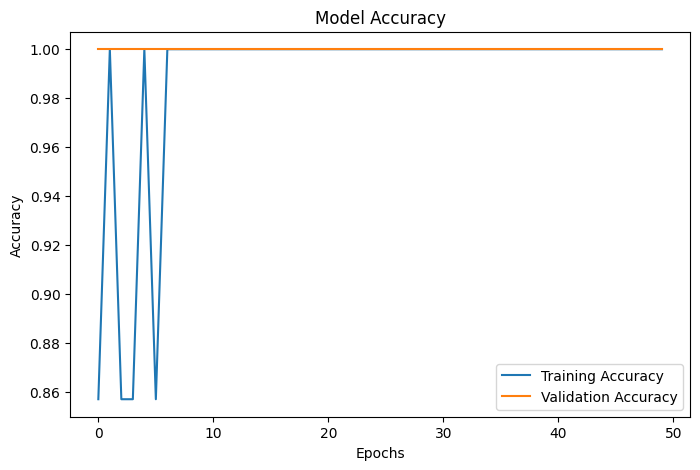

In [23]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')

plt.xlabel('Epochs')

plt.ylabel('Accuracy')

plt.legend()

plt.show()

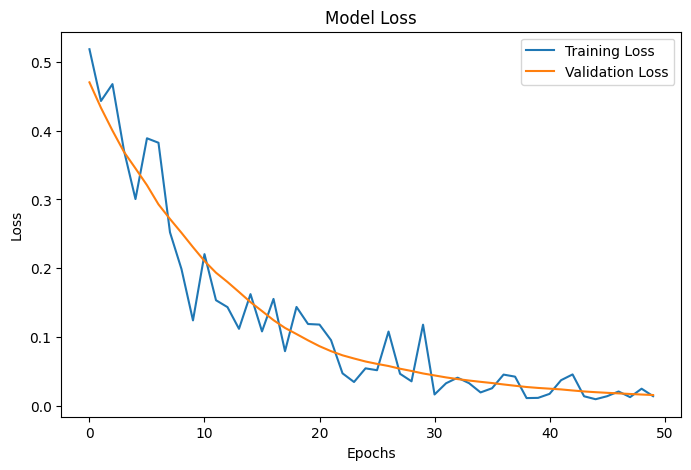

In [24]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')

plt.xlabel('Epochs')

plt.ylabel('Loss')

plt.legend()

plt.show()